# DSA 506 - Project #1

## **Deliverables**: 

**Interactive Dashboard** $\rightarrow$ Build and deploy an interactive dashboard using Streamlit (or an equivalent tool ). The dashboard should satisfy the following requirements:
1. Present at least four distinct visualizations that address your analytical questions. 
2. Include at least one interactive element that allows the user to filter, select, or adjust what is displayed. 
3. Provide brief contextual text within the dashboard that orients the user to the data, the questions being addressed, and how to interpret the visualizations. 
4. Deploy the dashboard to a publicly accessible and verify that it loads correctly before submission. 
5. Include a section or page within the dashboard that documents the data source, the date it was accessed, and how the data could be updated in the future to keep the dashboard current. 

Using Pokemon dataset, we are finding the four distinct: 
- Display Base Stat totals given a Pokemon (interactive)
- Which Pokemon have two different abilities 
- The frequency of each type (how often is flying paired w/another)
- Average Base Stat total for each type

In [2]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
college_admissions = pd.read_csv("genz_college_admission_prediction.csv")
college_admissions.describe() # Basic statistics such as the minimum age is 16, min income is about 21K, min gpa is 0.87

,student_id,age,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,19.000294,71701.069023,3.188329,1099.198467,23.468139,91.748151,2.999739,3.999927,99.452955,1.201223,1.999254,4.506180,1.997953,74.912247,77.954531,72.775141,0.881292
std,288675.278932,1.999321,47253.555181,0.476299,217.409113,5.908590,5.526156,1.729285,2.001495,50.019098,1.095605,1.414804,1.790163,1.414445,11.805257,9.873768,14.522840,0.323445
min,1.000000,16.000000,2124.000000,0.870000,400.000000,1.000000,63.200000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,17.600000,28.800000,0.500000,0.000000
25%,250000.750000,17.000000,39953.000000,2.860000,952.000000,19.000000,88.000000,2.000000,3.000000,63.000000,0.000000,1.000000,3.300000,1.000000,66.900000,71.300000,62.800000,1.000000
50%,500000.500000,19.000000,59877.000000,3.200000,1100.000000,24.000000,92.000000,3.000000,4.000000,91.000000,1.000000,2.000000,4.500000,2.000000,75.000000,78.000000,73.000000,1.000000
75%,750000.250000,21.000000,89688.000000,3.540000,1248.000000,28.000000,96.000000,4.000000,5.000000,127.000000,2.000000,3.000000,5.700000,3.000000,83.100000,84.700000,83.100000,1.000000
max,1000000.000000,22.000000,977775.000000,4.000000,1600.000000,36.000000,100.000000,12.000000,15.000000,517.000000,8.000000,11.000000,12.900000,12.000000,100.000000,100.000000,100.000000,1.000000


In [27]:
# Create a bar graph that represents that amount of students that were excepted into college and those that were not 
# O is not accepted and 1 is accepted

admission_status = college_admissions['admission_status'].value_counts() # Count how many people survived 
admission_status
# 881292 were accepted and 118708 were not accepted 
accepted = (admission_status.values[0] / 1000000) * 100
print(accepted)
rejected = admission_status.values[1] / 1000000 * 100
print(rejected)

88.1292
11.8708


In [36]:
gender = college_admissions['gender'].value_counts() 
gender

gender
Male      490475
Female    489414
Other      20111
Name: count, dtype: int64

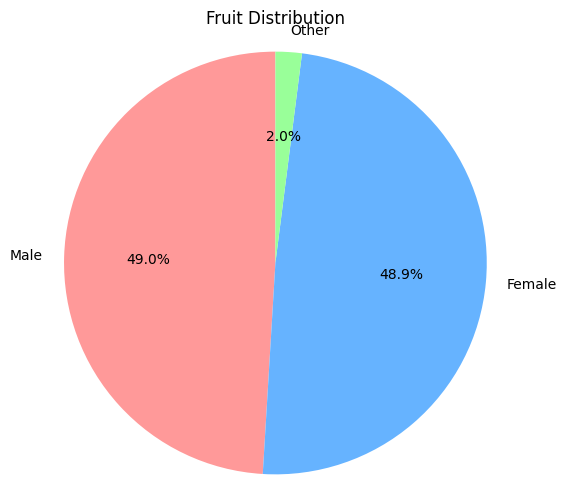

In [ ]:
import matplotlib.pyplot as plt

# Data
labels = gender.index
sizes = gender.values
# colors = ['#ff9999', '#66b3ff', '#99ff99']
# The gender split is pretty even with about 2% of people identifying outside of male or female. 

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Fruit Distribution')
plt.axis('equal')  # Keeps it a perfect circle
plt.show()

<Axes: xlabel='admission_status', ylabel='ap_courses'>

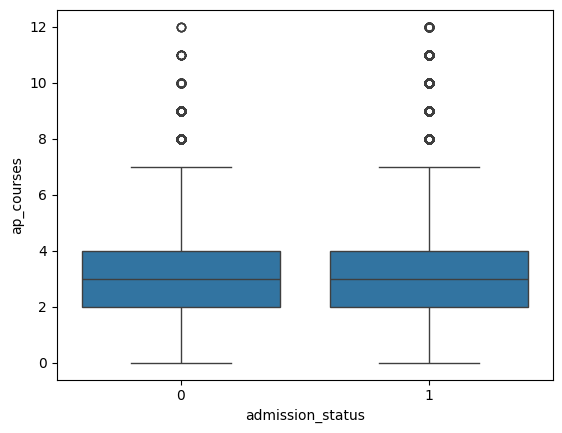

In [ ]:
sns.boxplot(x=college_admissions['admission_status'],y=college_admissions['ap_courses'])
# AP course scores don't seem to impact acceptance or rejection as the the students who were rejected had a similar ap score profile compared to those that 
# were accepted

(array([2.90000e+01, 2.95000e+02, 2.24600e+03, 1.31260e+04, 4.75640e+04,
        1.18336e+05, 2.11497e+05, 2.44097e+05, 1.96672e+05, 1.66138e+05]),
 array([0.87 , 1.183, 1.496, 1.809, 2.122, 2.435, 2.748, 3.061, 3.374,
        3.687, 4.   ]),
 <BarContainer object of 10 artists>)

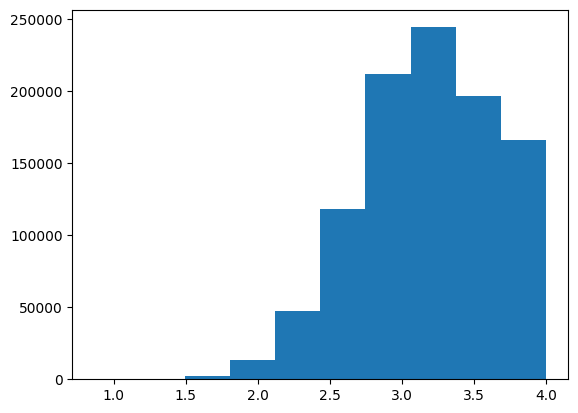

In [67]:
plt.hist(college_admissions['high_school_gpa'])


<Axes: xlabel='gender', ylabel='count'>

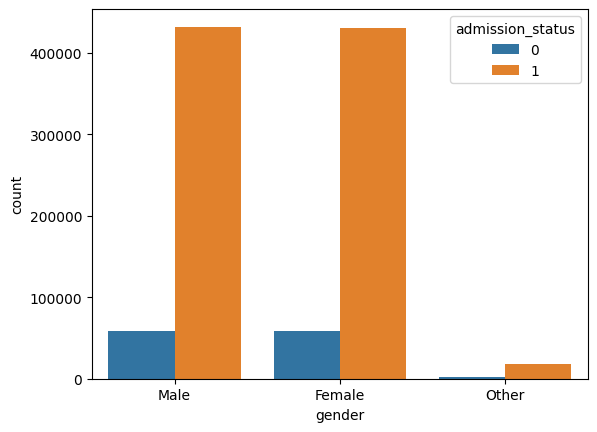

In [34]:

sns.countplot(x='gender',hue='admission_status', data = college_admissions)

<Axes: ylabel='age'>

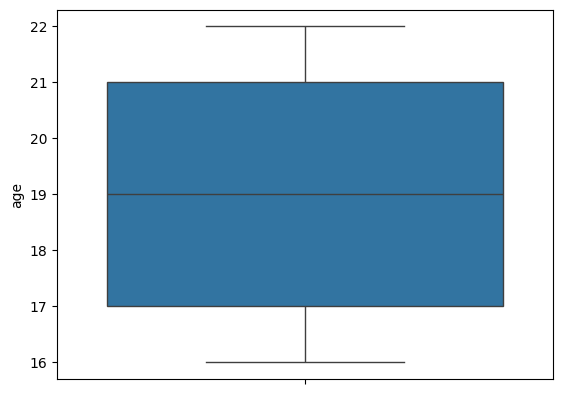

In [ ]:


sns.boxplot(y = college_admissions['age'])

# The students seem to be in the age range of 16 to 22 years old which is pretty consistent with the average age of students applying for various college programs. 
# Based on the boxplot, there aren't too many outliers available. 

In [79]:
state = college_admissions[college_admissions['state'] == 'California']
state.describe()

,student_id,age,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
count,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000,99938.000000
mean,500781.213843,19.002151,71608.602273,3.186573,1098.906272,23.480078,91.746727,3.002712,3.982129,99.307621,1.205998,1.998949,4.500902,1.999820,74.860005,77.948848,72.776740,0.880386
std,288918.082886,1.996115,47045.558069,0.476157,217.326721,5.891341,5.544813,1.730685,1.990864,49.710058,1.096238,1.420775,1.787330,1.411785,11.816236,9.879717,14.551433,0.324511
min,6.000000,16.000000,4726.000000,1.080000,400.000000,1.000000,63.200000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,17.600000,36.600000,8.500000,0.000000
25%,250871.750000,17.000000,39791.500000,2.860000,952.000000,19.000000,88.000000,2.000000,3.000000,63.000000,0.000000,1.000000,3.300000,1.000000,66.800000,71.200000,62.800000,1.000000
50%,500435.500000,19.000000,59913.000000,3.200000,1100.000000,24.000000,92.000000,3.000000,4.000000,91.000000,1.000000,2.000000,4.500000,2.000000,74.900000,78.000000,73.000000,1.000000
75%,752427.500000,21.000000,89567.500000,3.530000,1247.000000,28.000000,96.000000,4.000000,5.000000,127.000000,2.000000,3.000000,5.700000,3.000000,83.100000,84.700000,83.200000,1.000000
max,1000000.000000,22.000000,977775.000000,4.000000,1600.000000,36.000000,100.000000,12.000000,15.000000,458.000000,8.000000,11.000000,11.600000,10.000000,100.000000,100.000000,100.000000,1.000000


<BarContainer object of 10 artists>

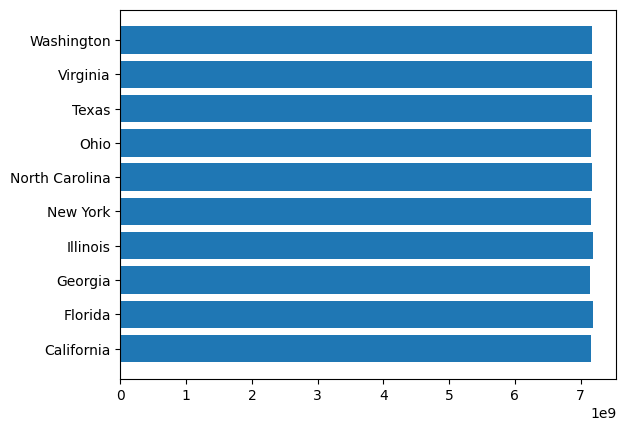

In [61]:

x = college_admissions.groupby('state')['family_income'].sum()
plt.barh(x.index,x.values)

<Axes: xlabel='family_income', ylabel='high_school_gpa'>

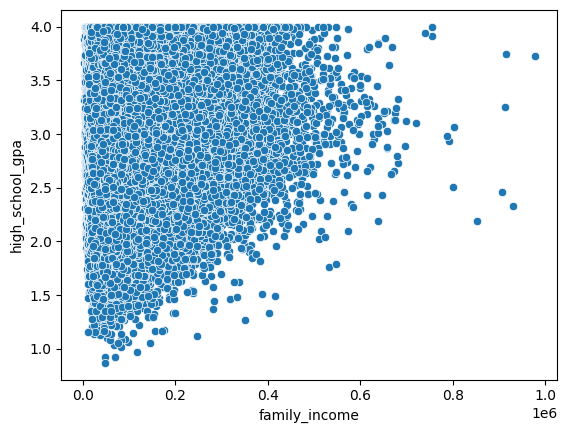

In [73]:
sns.scatterplot(college_admissions, x='family_income', y='high_school_gpa')

**Video Presentation** $\rightarrow$ Record a video presentation of no more than five minutes. The video should be structured for the data's target audience, not for an academic or technical audience. It should cover the following elements:
1. The problem or decision context that motivates the analysis. 
2. A walkthrough of the key findings, using the dashboard or selected visualizations as supporting material. 
3. The storytelling arc connecting the original questions to the evidence and conclusions. 
4. Actionable insights or recommendations derived from the analysis. 
5. No code, no technical jargon unexplained to the audience, and no screen recordings of development environments. The presentation should feel like a briefing or a data journalism segment, not a code walkthrough

**Written Summary** $\rightarrow$ Submit a brief written document (two to three pages) that complements the dashboard 
and video. This summary should include the following:
1. A description of the dataset, including source, size, key variables, and any preprocessing performed. 
2. The analytical questions posed in Phase 1 and how they evolved during the project. 
3. A brief account of the QUEST phases as applied in your project. 
4. A reflection on what the data revealed, what limitations you encountered, and what further analysis could be pursued.